# LangMem (Demo)


In [7]:
from langchain.agents import create_agent
from langgraph.store.memory import InMemoryStore
from langmem import create_manage_memory_tool, create_search_memory_tool
from langchain_core.messages import HumanMessage

In [8]:
from dotenv import load_dotenv
load_dotenv()

True

In [9]:
store = InMemoryStore(
    index={
        "dims": 1536,
        "embed": "openai:text-embedding-3-small",
    }
)

In [10]:
agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[
        # Memory tools use LangGraph's BaseStore for persistence
        create_manage_memory_tool(namespace=("memories",)),
        create_search_memory_tool(namespace=("memories",)),
    ],
    store=store,
)

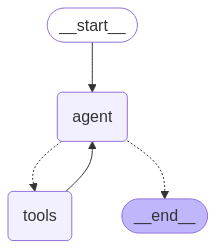

In [5]:
agent

In [11]:
agent.get_input_jsonschema()

{'$defs': {'AIMessage': {'additionalProperties': True,
   'description': 'Message from an AI.\n\nAn `AIMessage` is returned from a chat model as a response to a prompt.\n\nThis message represents the output of the model and consists of both\nthe raw output as returned by the model and standardized fields\n(e.g., tool calls, usage metadata) added by the LangChain framework.',
   'properties': {'content': {'anyOf': [{'type': 'string'},
      {'items': {'anyOf': [{'type': 'string'},
         {'additionalProperties': True, 'type': 'object'}]},
       'type': 'array'}],
     'title': 'Content'},
    'additional_kwargs': {'additionalProperties': True,
     'title': 'Additional Kwargs',
     'type': 'object'},
    'response_metadata': {'additionalProperties': True,
     'title': 'Response Metadata',
     'type': 'object'},
    'type': {'const': 'ai',
     'default': 'ai',
     'title': 'Type',
     'type': 'string'},
    'name': {'anyOf': [{'type': 'string'}, {'type': 'null'}],
     'default'

In [12]:
# Ask a random question to the agent
output = agent.invoke(
    input = {
        "messages": [
            {
                "role": "user", 
                "content": "What are my lighting preferences?"
            }
        ]
    },
    config = {"configurable": {"thread_id": "1"}}
)

output['messages']

[HumanMessage(content='What are my lighting preferences?', additional_kwargs={}, response_metadata={}, id='3f65827d-a1d8-4dc5-ab6b-65e64c00c6ce'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 246, 'total_tokens': 261, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'id': 'chatcmpl-DrW5xjuT8DJbTPLPakL2PLG6dQ52p', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ed271-b95d-7603-aecb-b1d5fdb1d380-0', tool_calls=[{'name': 'search_memory', 'args': {'query': 'lighting preferences'}, 'id': 'call_TcXOBQn31JMY0kv7rgCnWzLZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

In [13]:
messages = output['messages']

In [14]:
messages.append(HumanMessage("Ok. Remember that I prefer dark mode."))

In [15]:
# Store a new memory in one Session
output = agent.invoke(
    input = {
        "messages": messages,
    },
    config = {"configurable": {"thread_id": "1"}}
)

output['messages']

[HumanMessage(content='What are my lighting preferences?', additional_kwargs={}, response_metadata={}, id='3f65827d-a1d8-4dc5-ab6b-65e64c00c6ce'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 246, 'total_tokens': 261, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'id': 'chatcmpl-DrW5xjuT8DJbTPLPakL2PLG6dQ52p', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ed271-b95d-7603-aecb-b1d5fdb1d380-0', tool_calls=[{'name': 'search_memory', 'args': {'query': 'lighting preferences'}, 'id': 'call_TcXOBQn31JMY0kv7rgCnWzLZ', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2

In [16]:
# Retrieve the stored memory in another Session
output = agent.invoke(
    {
        "messages": [
            {
                "role": "user", 
                "content": "What are my lighting preferences?"
            }
        ]
    },
    config = {"configurable": {"thread_id": "2"}}
)

output['messages']

[HumanMessage(content='What are my lighting preferences?', additional_kwargs={}, response_metadata={}, id='40e606bf-1024-4e7d-adee-85f1bdd43784'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 246, 'total_tokens': 261, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_5a76486b9e', 'id': 'chatcmpl-DrW6JxOPXm2BnutLd6LGtXMTCyVhM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ed272-0ea1-73c1-bff3-3a22fd524805-0', tool_calls=[{'name': 'search_memory', 'args': {'query': 'lighting preferences'}, 'id': 'call_uMibE709hMmYfnRsbNKwhmIN', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2